In [1]:
import os
from pathlib import Path 

import cv2 
import numpy as np
import IPython
from tqdm.auto import tqdm 
from retinaface import RetinaFace

/home/amos/anaconda3/envs/retina/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-05-13 21:00:57.145852: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-13 21:00:58.354552: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def draw_faces(image, faces):
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
cap = cv2.VideoCapture('/home/amos/programs/CineFace/data/test_videos/shining_bat.mp4')
ret, frame = cap.read()
print(ret)

True


In [5]:
src = '../images/img_5.jpg'
img = cv2.imread(src)
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

2024-05-13 20:58:18.928548: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-13 20:58:18.954727: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-13 20:58:18.954884: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [ ]:
img = cv2.imread('./images/img_2.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

In [ ]:
img = cv2.imread('./images/img_3.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

In [ ]:
img = cv2.imread('./images/img_4.jpg')
faces = RetinaFace.detect_faces(img, threshold=0.1)
draw_faces(img, faces)
show_image(img)

In [ ]:
img = cv2.imread('./images/img_5.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

In [ ]:
img = cv2.imread('./images/img_6.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

In [ ]:
cap = cv2.VideoCapture('./data/test.mkv')
_, frame = cap.read()
show_image(frame)

  0%|          | 0/8553 [00:00<?, ?it/s]2024-05-13 21:01:21.619031: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-13 21:01:21.979980: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-13 21:01:21.980176: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Docum

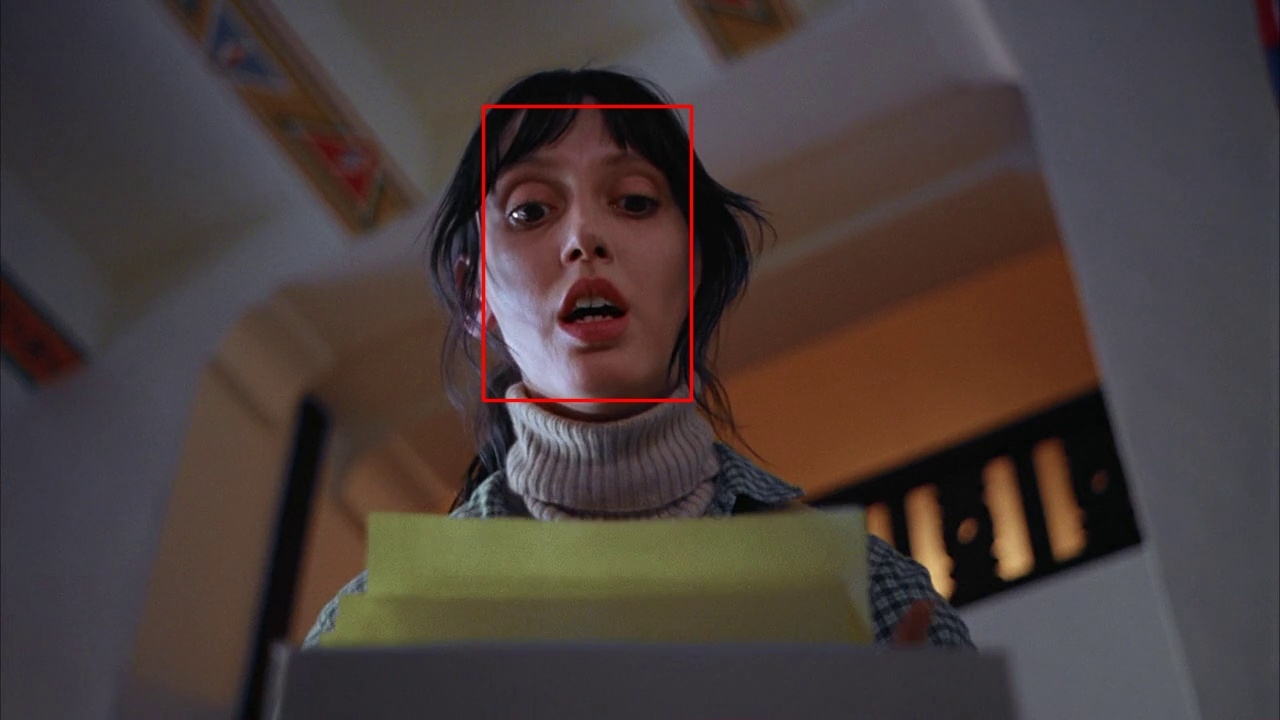

24


In [5]:
cap.read()
cnt = 1
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    ret, frame = cap.read()
    if not ret or frame is None:
            break 
    elif cnt % 24 == 0:
        faces = RetinaFace.detect_faces(frame)
        if not faces:
            pb.update(1)
            cnt += 1
            continue
        draw_faces(frame, faces)
        show_image(frame)
        break
    cnt += 1
    pb.update(1)
print(cnt)
        

In [9]:
cap.read()

(False, None)

In [7]:
RetinaFace.detect_faces(np.array(images))

ValueError: Input image needs to have 3 channels at must not be empty.

In [9]:
np.array(images).shape

(2, 1080, 1920, 3)